# @ import libraries

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# @ Load dataset

In [42]:
df = pd.read_csv('decision_tree_dataset.csv')

In [43]:
df.head()

,age,income,credit_score,city,gender,purchases,loan_amount,approved
0,41,16832.970365,646.435852,Hyderabad,Female,2,NaN,0
1,61,24958.920783,772.103370,Bangalore,Female,2,109037.369348,0
2,29,26661.565307,742.165011,Bangalore,Male,3,140981.063625,0
3,40,76918.367953,789.568381,Mumbai,Female,2,265765.286243,0
4,18,33446.160242,650.679984,Delhi,Male,4,187481.809910,0


In [44]:
df.shape

(1050, 8)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           1050 non-null   int64  
 1   income        947 non-null    float64
 2   credit_score  946 non-null    float64
 3   city          1050 non-null   object 
 4   gender        1050 non-null   object 
 5   purchases     1050 non-null   int64  
 6   loan_amount   947 non-null    float64
 7   approved      1050 non-null   int64  
dtypes: float64(3), int64(3), object(2)
memory usage: 65.8+ KB


In [46]:
# check the missing values in the dataset
df.isnull().sum()

age               0
income          103
credit_score    104
city              0
gender            0
purchases         0
loan_amount     103
approved          0
dtype: int64

In [47]:
df.describe()

,age,income,credit_score,purchases,loan_amount,approved
count,1050.000000,947.000000,946.000000,1050.000000,9.470000e+02,1050.000000
mean,43.737143,55807.648029,651.605495,2.934286,2.086066e+05,0.303810
std,15.021797,40021.647680,100.166162,1.603281,1.270517e+05,0.460121
min,18.000000,6556.169327,348.048784,0.000000,-5.768131e+04,0.000000
25%,31.000000,40886.541936,584.998140,2.000000,1.378232e+05,0.000000
50%,44.000000,50967.116222,650.052796,3.000000,1.971923e+05,0.000000
75%,56.000000,60643.014837,718.563117,4.000000,2.598691e+05,1.000000
max,69.000000,445126.233564,969.310757,9.000000,1.233105e+06,1.000000


In [48]:
# data visualization
sns



<module 'seaborn' from 'c:\\Users\\MY PC\\anaconda3\\Lib\\site-packages\\seaborn\\__init__.py'>

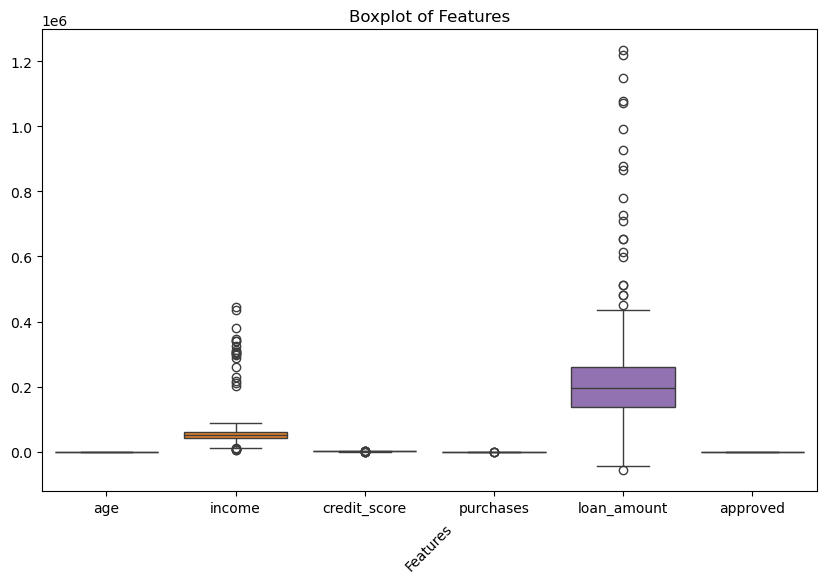

In [49]:
# make boxplotto check the outliers in the dataset

plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.title('Boxplot of Features')
plt.xlabel('Features', rotation=45)
plt.show()


In [50]:
# handle the missing the values

# find the all columns which have missing values
income_median = round(df['income'].median(), 2)
credit_score_median = round(df['credit_score'].median(), 2)
loan_amount_median = round(df['loan_amount'].median(), 2)

# fill the missing values with mean and median
df['income'].fillna(income_median, inplace=True)
df['credit_score'].fillna(credit_score_median, inplace=True)  
df['loan_amount'].fillna(loan_amount_median, inplace=True)

C:\Users\MY PC\AppData\Local\Temp\ipykernel_11456\2392015989.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['income'].fillna(income_median, inplace=True)
C:\Users\MY PC\AppData\Local\Temp\ipykernel_11456\2392015989.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

In [51]:
# handle the outliers using iqr method
outlier_columns = ['income', 'credit_score', 'loan_amount']

for column in outlier_columns:

    # find Quartiles
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    # find IQR
    IQR = Q3 - Q1

    # find lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # handle the outliers clipping the values to the lower and upper bounds
    df[column] = np.clip(df[column], lower_bound, upper_bound)
    

In [52]:
df['city'].value_counts()

city
Delhi        268
Bangalore    262
Mumbai       261
Hyderabad    259
Name: count, dtype: int64

In [53]:
# drop the city  column as it is not useful for the model 
df.drop('city', axis=1, inplace=True)

In [54]:
# replace the gender column values with 0 and 1
df['gender'] = df['gender'].replace({'Male': 0, 'Female': 1})



C:\Users\MY PC\AppData\Local\Temp\ipykernel_11456\1111920916.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'] = df['gender'].replace({'Male': 0, 'Female': 1})


In [55]:
# split the dataest into features and target variable
X = df.drop('approved', axis=1)
y = df['approved']

In [56]:
# split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [57]:
X_test.head()

,age,income,credit_score,gender,purchases,loan_amount
352,53,58081.339887,773.578219,1,1,243845.353977
689,36,52947.817546,702.112243,1,3,354668.779817
485,18,47838.686664,611.290030,1,5,195935.936910
388,52,53358.260364,650.050000,1,4,227148.465020
31,23,58250.781485,607.075558,1,6,204244.745035


In [58]:
# handle the imbalance in the dataset usiing RandomOverSampler technique
from imblearn.over_sampling import RandomOverSampler

# instance of RandomOverSampler
ros = RandomOverSampler(random_state=42)

# fit and transform the training data
X_train_resampled, y_train_resampled = ros.fit_resample(X,y)


In [ ]:
# smote technique
from imblearn.over_sampling import SMOTE
# instance of SMOTE
smote = SMOTE(random_state=42)




In [61]:
# model building

from sklearn.linear_model import LogisticRegression

# instance of LogisticRegression
lr = LogisticRegression()

# train the model using X_trian and y_train
model  = lr.fit(X_train, y_train)

# predict the target variable using X_test
y_pred = model.predict(X_test)

c:\Users\MY PC\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [62]:
# model Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# find the accuracy
accuracy = accuracy_score(y_test, y_pred)

# find the confusion matrix
confusion = confusion_matrix(y_test, y_pred)

# find the classification report
report = classification_report(y_test, y_pred)

# 

In [63]:
print("Accuracy: ", accuracy)

Accuracy:  0.680952380952381


In [65]:
print(" confusion matrix: ", confusion)


 confusion matrix:  [[131  21]
 [ 46  12]]


In [66]:
print("classification report: ", report)

classification report:                precision    recall  f1-score   support

           0       0.74      0.86      0.80       152
           1       0.36      0.21      0.26        58

    accuracy                           0.68       210
   macro avg       0.55      0.53      0.53       210
weighted avg       0.64      0.68      0.65       210



In [ ]:
print 